# Initial Data Profiling

Este notebook apresenta uma inspeção inicial automatizada do dataset movies utilizando ferramentas de data profiling.

O objetivo desta etapa é identificar rapidamente:

- inconsistências estruturais;
- valores ausentes;
- distribuições;
- possíveis outliers;
- padrões preliminares;
- problemas de qualidade dos dados.

As observações obtidas aqui servirão de apoio para as etapas posteriores de limpeza e análise exploratória detalhada.

In [1]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..')))


# Importação de Bibliotecas e Módulos
import numpy as np
import pandas as pd
import seaborn as sns
import sweetviz as sv
import matplotlib.pyplot as plt


# Nossos módulos customizados da pasta src/
import src.io.data_loader as dl
import src.utils.data_quality as dq
import src.view.plots as graf
import src.view.tables as tb

---
## Carregando Dados

In [2]:
caminho = '../data/raw/movies/movies_dataset/movies_metadata.csv'
df_movies = dl.load_data(caminho, tipo_arquivo='csv')

Dados CSV carregados! Formato: (45466, 24)


---
## Exploração Inicial - Visão Geral

In [3]:
df_movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [4]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [5]:
df_movies.shape

(45466, 24)

In [6]:
df_movies.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [7]:
df_movies.describe()

,revenue,runtime,vote_average,vote_count
count,4.546000e+04,45203.000000,45460.000000,45460.000000
mean,1.120935e+07,94.128199,5.618207,109.897338
std,6.433225e+07,38.407810,1.924216,491.310374
min,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,85.000000,5.000000,3.000000
50%,0.000000e+00,95.000000,6.000000,10.000000
75%,0.000000e+00,107.000000,6.800000,34.000000
max,2.787965e+09,1256.000000,10.000000,14075.000000


---
## Filtrando dataset

Algumas colunas textuais e variáveis de alta cardinalidade seram removidas da etapa de profiling automatizado devido a limitações de visualização e baixa relevância estatística para análise univariada inicial.

In [8]:
df_profile = df_movies.copy()

Testando: adult


                                             |          | [  0%]   00:00 -> (? left)


ERRO NA COLUNA: adult
left cannot be >= right


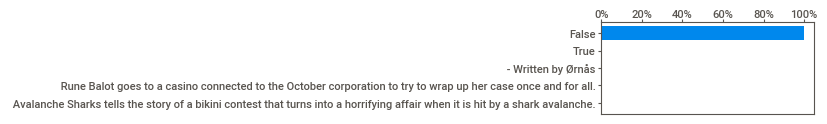

In [9]:
for col in df_profile.columns:

    try:

        print(f'Testando: {col}')

        report = sv.analyze(df_profile[[col]])

    except Exception as e:

        print(f'\nERRO NA COLUNA: {col}')
        print(e)
        break

In [10]:
df_profile = df_profile.drop(columns='adult')

---
## Geração do relatório

                                             |          | [  0%]   00:00 -> (? left)


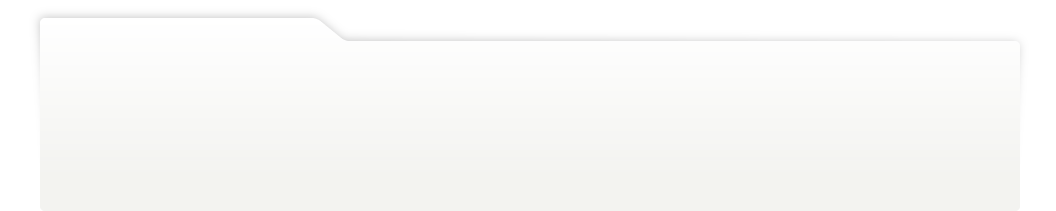
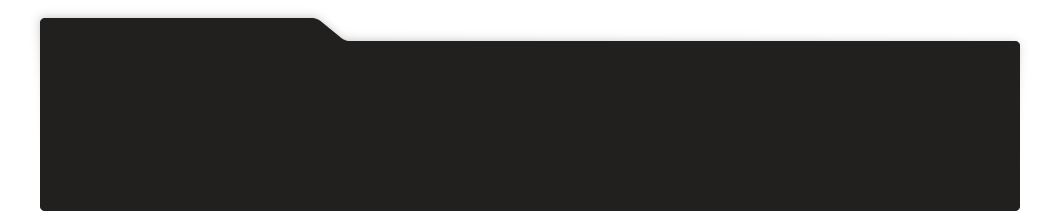
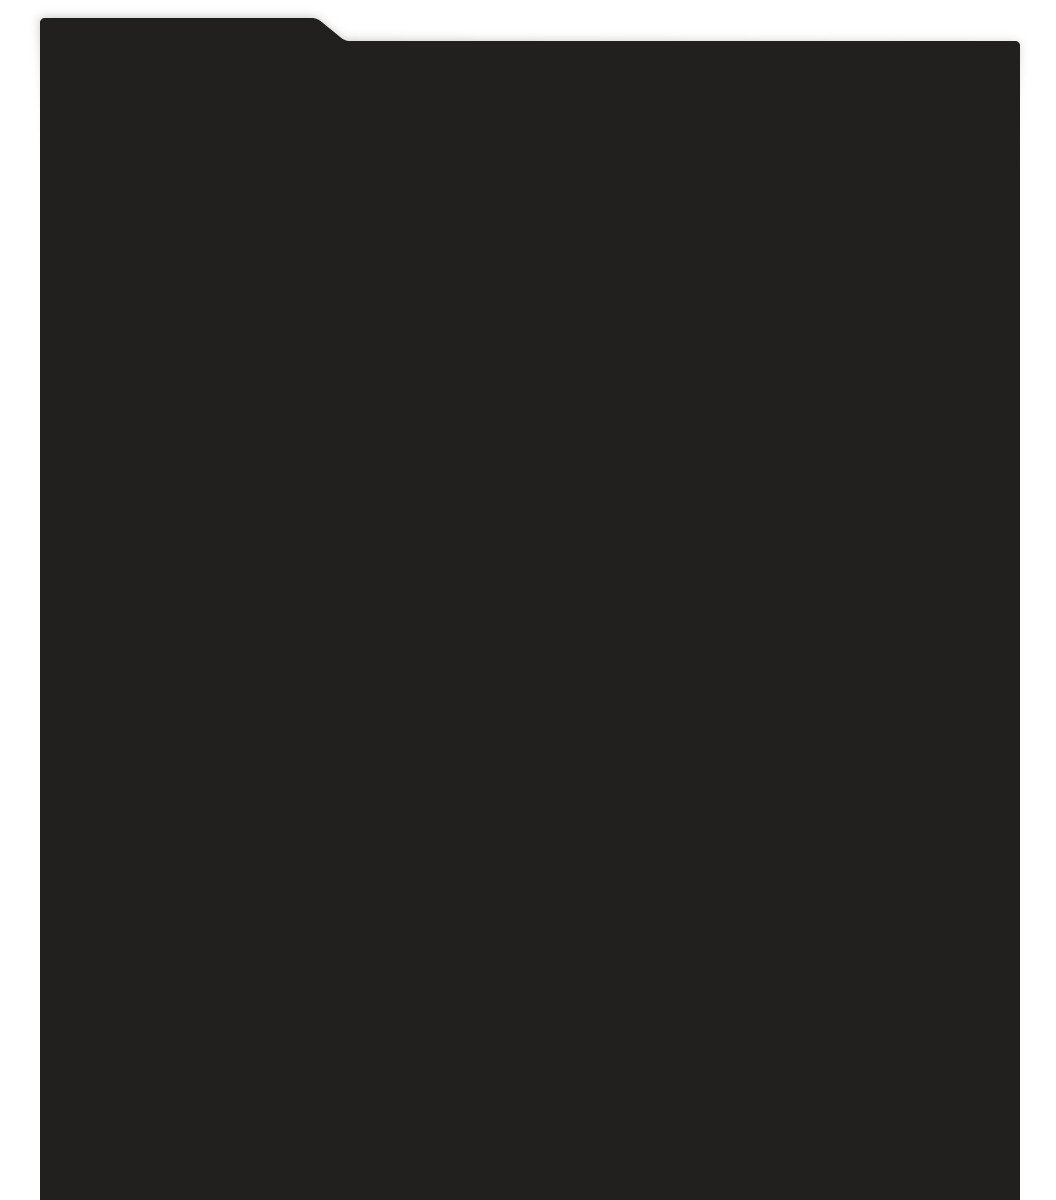
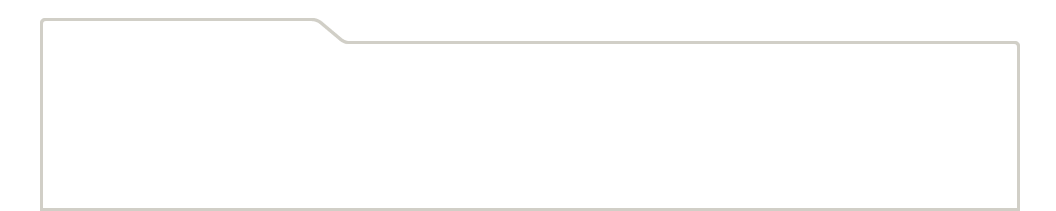
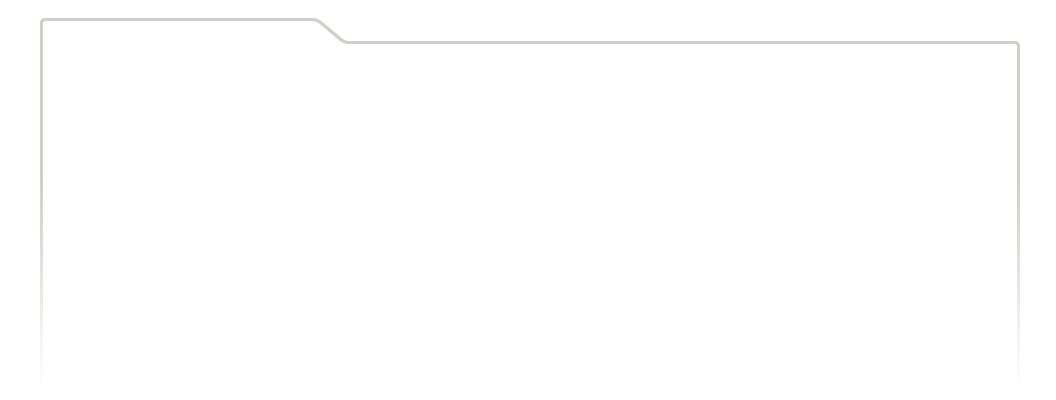
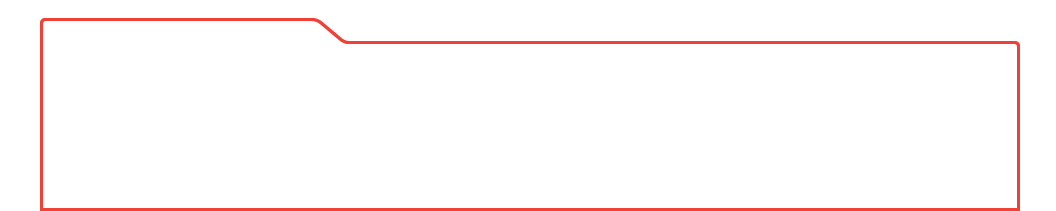
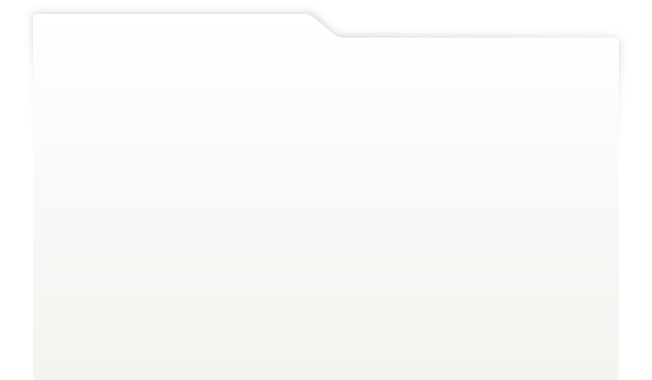
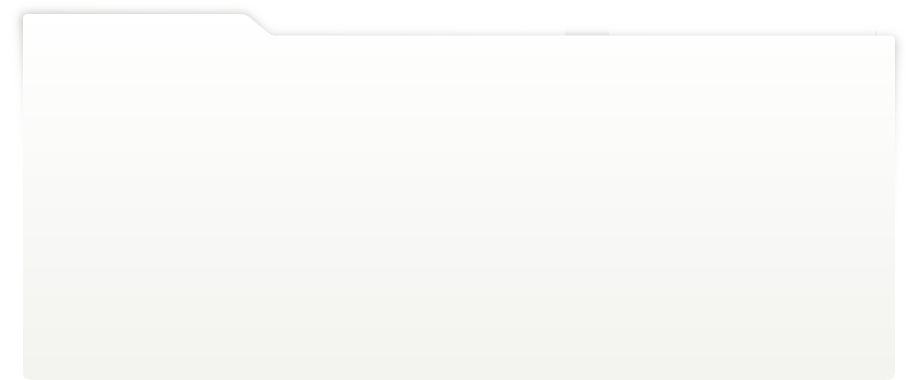
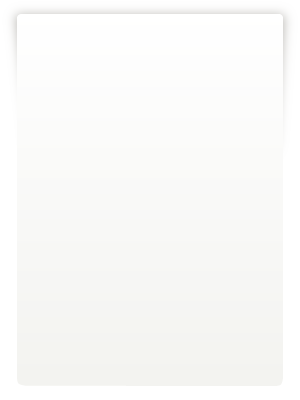
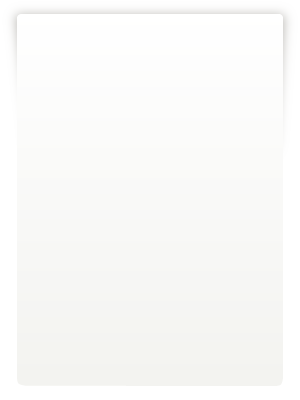
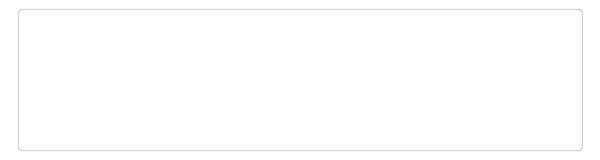
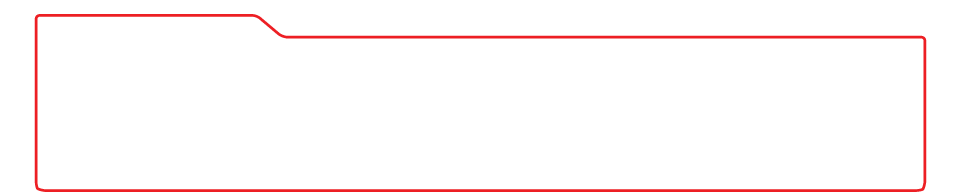
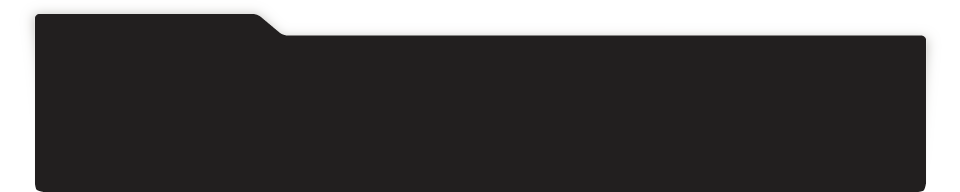
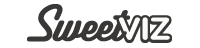
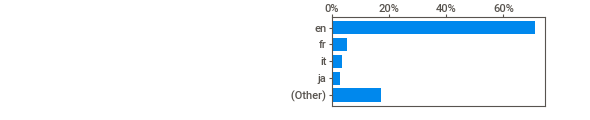
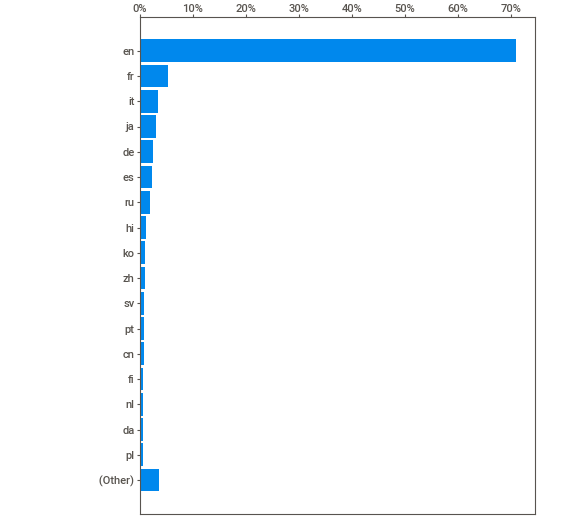
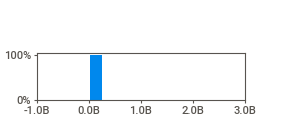
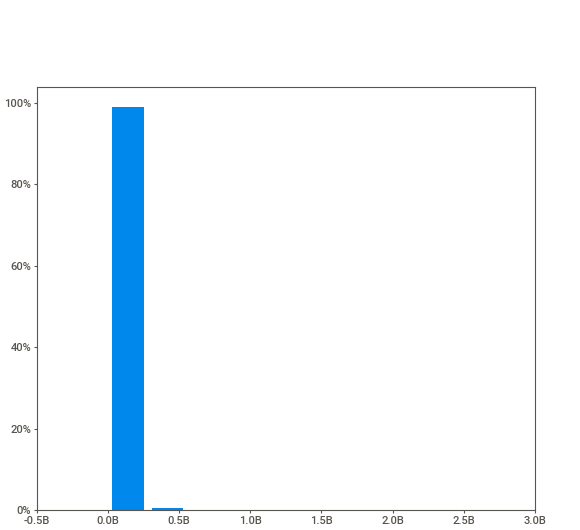
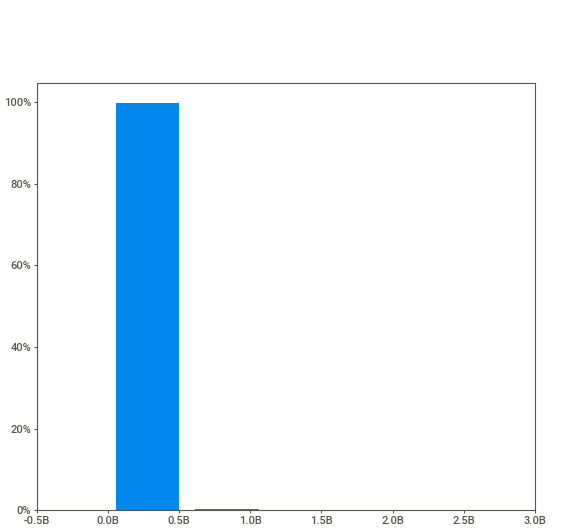
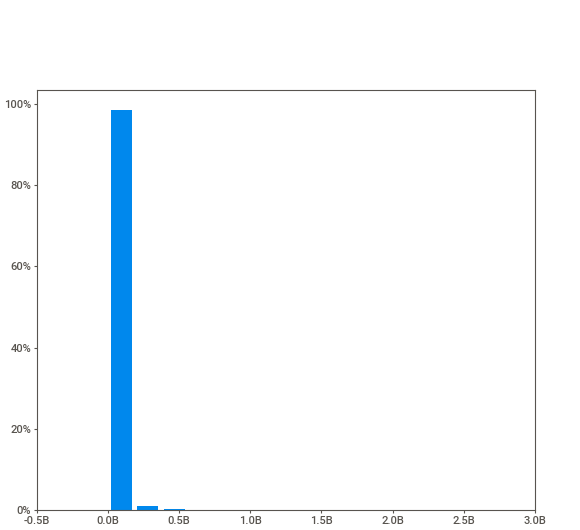
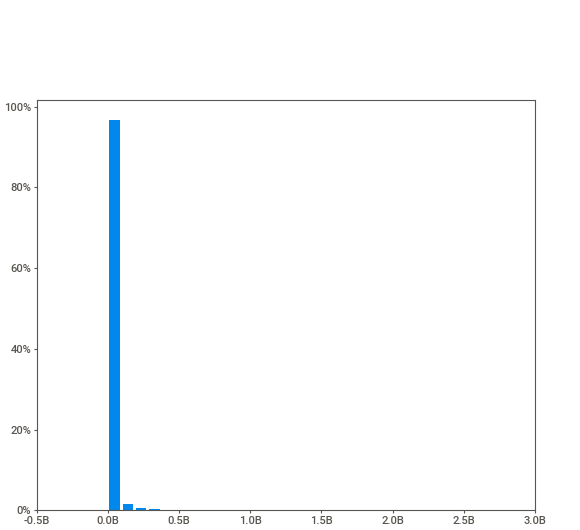
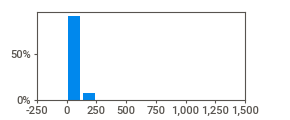
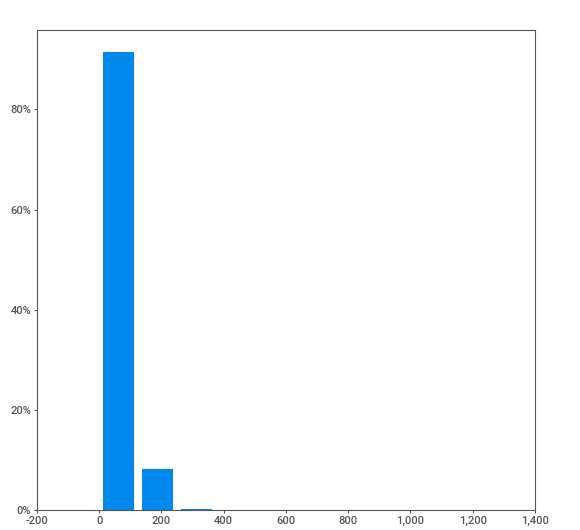
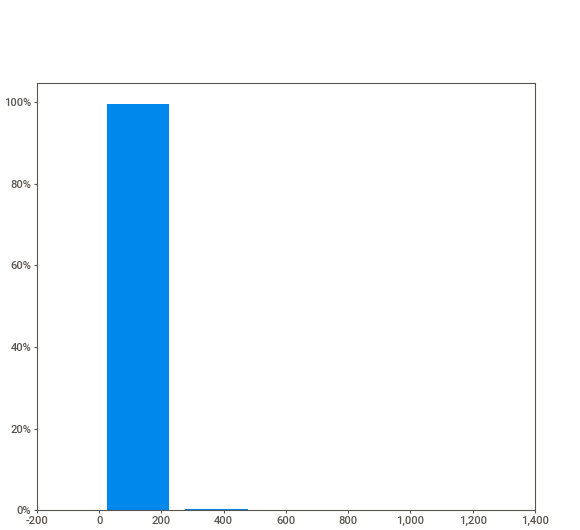
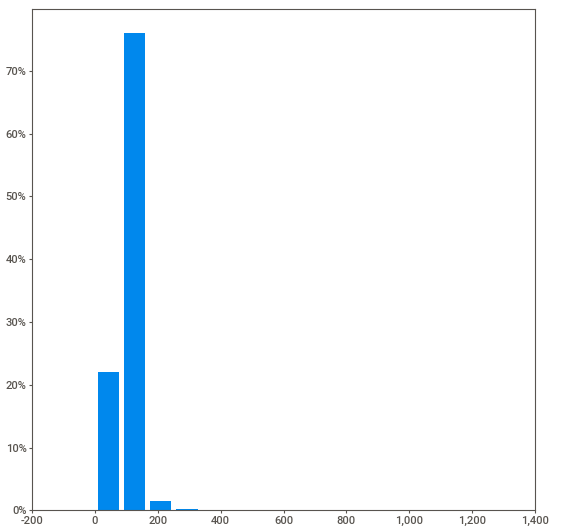
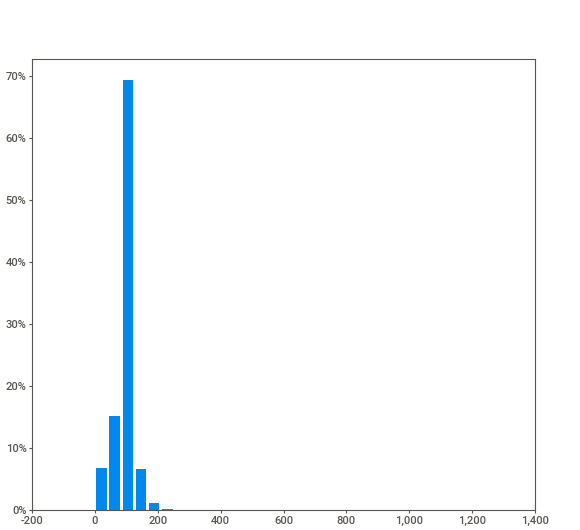
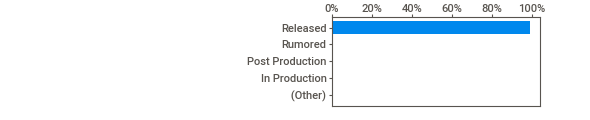
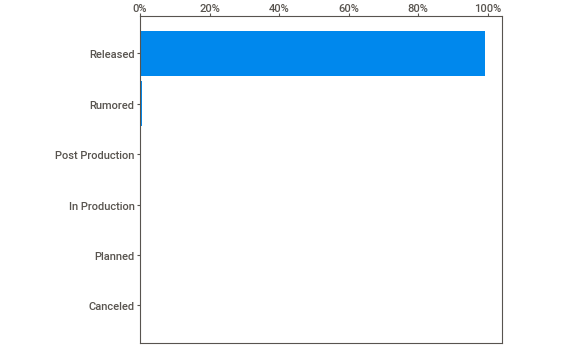
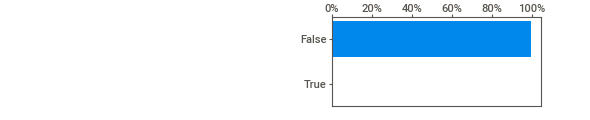
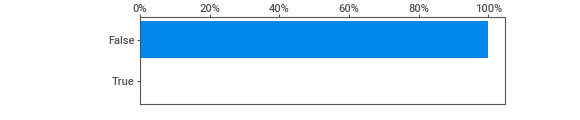
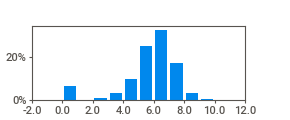
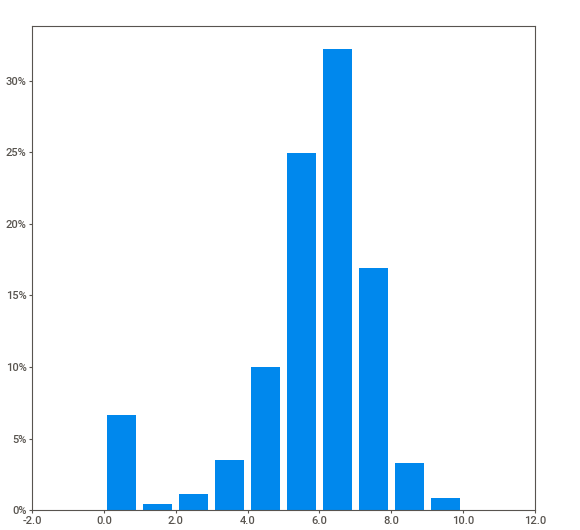
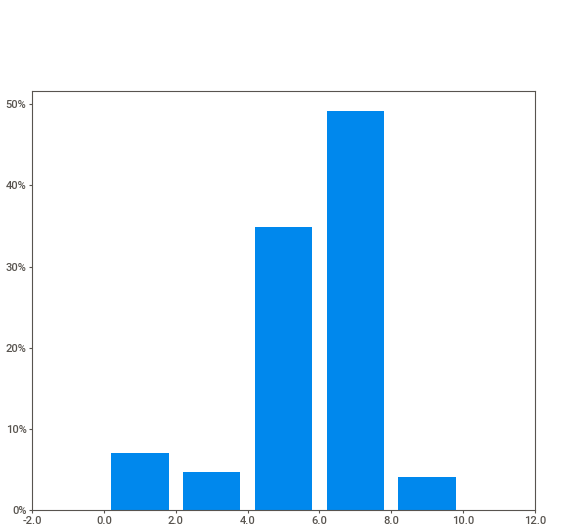
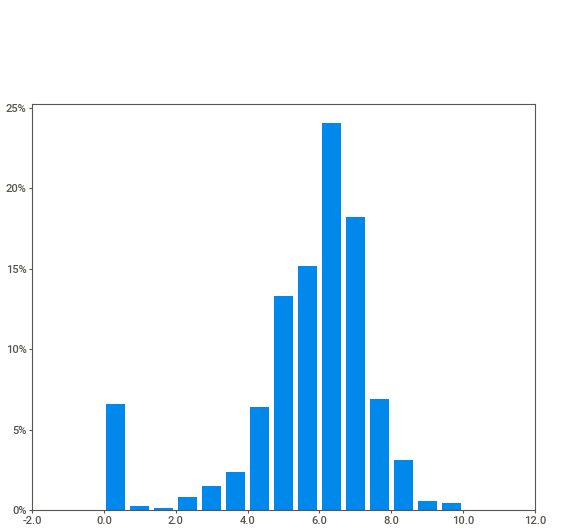
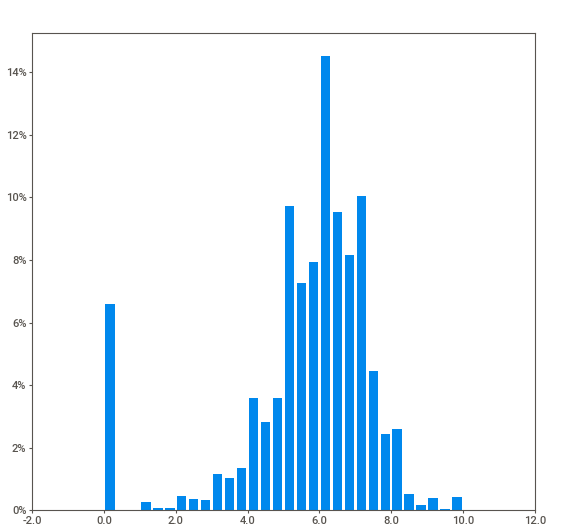
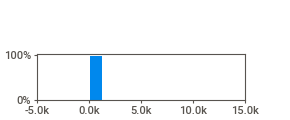
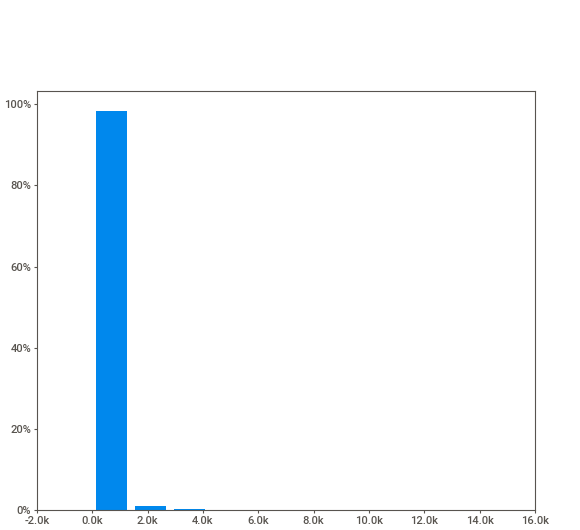
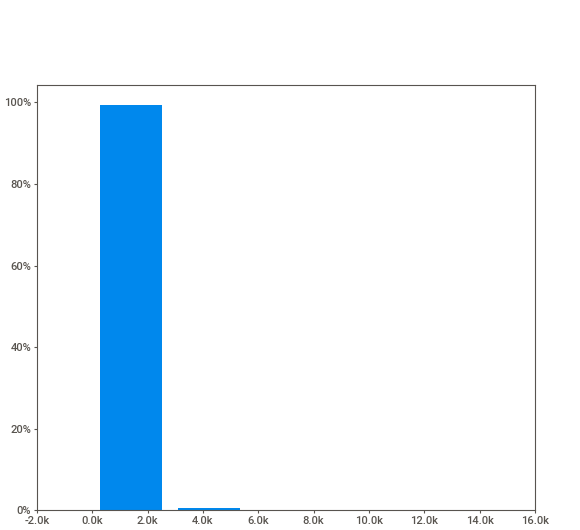
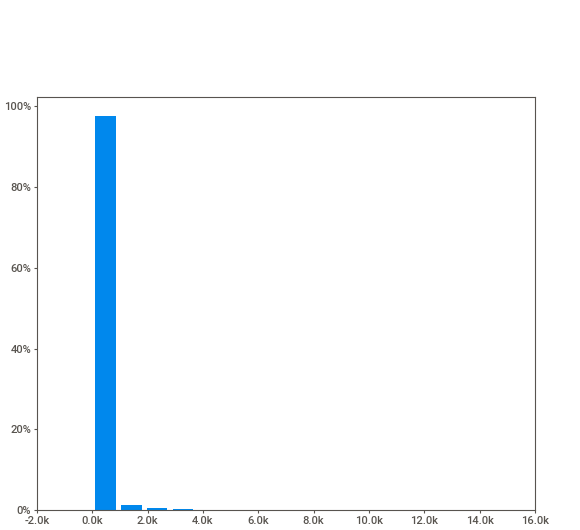
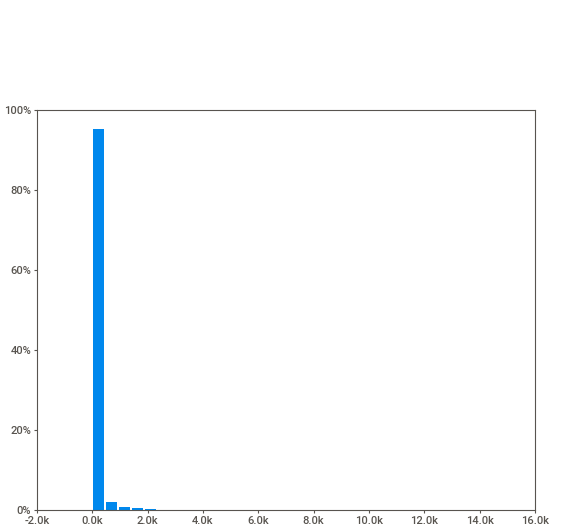
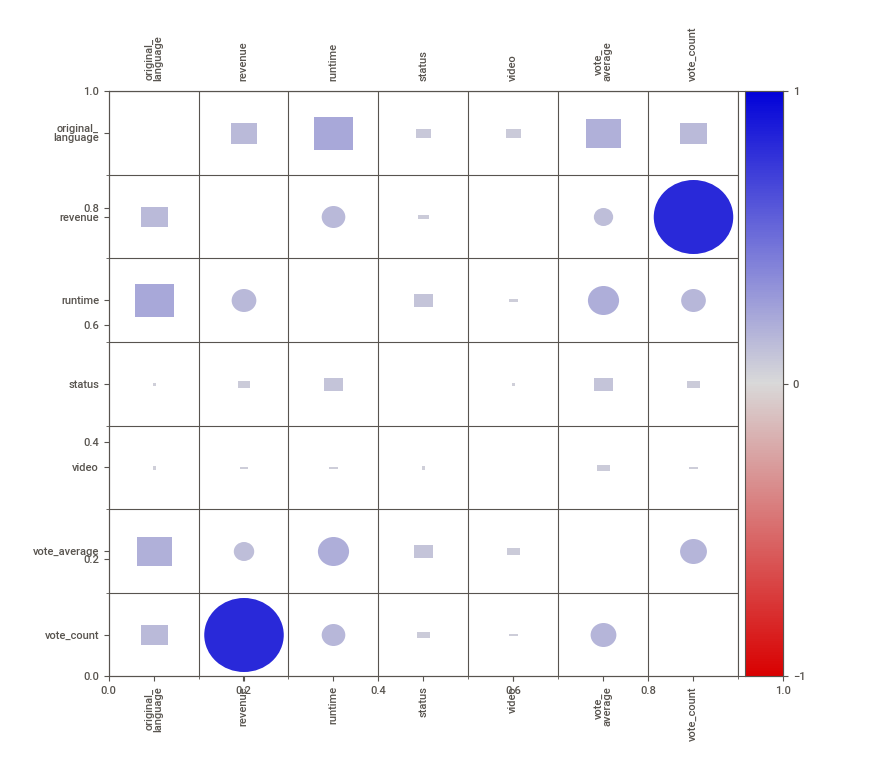
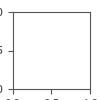

In [11]:
report = sv.analyze(df_profile)

report.show_notebook()

---
## Tipos de Dados

In [12]:

display(tb.estilizar_tabela(
    df=df_movies.select_dtypes(include=['object', 'string']),
    qtd_linhas=10,
    caption="Tipos textuais (Object/String)"
))

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,spoken_languages,status,tagline,title,video
0,False,"{'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg', 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.jpg'}","US$ 30,000,000","[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.",21.95,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-10-30,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,nan,Toy Story,False
1,False,nan,"US$ 65,000,000","[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 10751, 'name': 'Family'}]",nan,8844,tt0113497,en,Jumanji,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures.",17.02,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'name': 'Teitler Film', 'id': 2550}, {'name': 'Interscope Communications', 'id': 10201}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-15,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': 'fr', 'name': 'Français'}]",Released,Roll the dice and unleash the excitement!,Jumanji,False
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collection', 'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg', 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.jpg'}",US$ 0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, 'name': 'Comedy'}]",nan,15602,tt0113228,en,Grumpier Old Men,"A family wedding reignites the ancient feud between next-door neighbors and fishing buddies John and Max. Meanwhile, a sultry Italian divorcée opens a restaurant at the local bait shop, alarming the locals who worry she'll scare the fish away. But she's less interested in seafood than she is in cooking up a hot time with Max.",11.71,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name': 'Lancaster Gate', 'id': 19464}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-22,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for Love.,Grumpier Old Men,False
3,False,nan,"US$ 16,000,000","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10749, 'name': 'Romance'}]",nan,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the women are holding their breath, waiting for the elusive ""good man"" to break a string of less-than-stellar lovers. Friends and confidants Vannah, Bernie, Glo and Robin talk it all out, determined to find a better way to breathe.",3.86,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,"[{'name': 'Twentieth Century Fox Film Corporation', 'id': 306}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",1995-12-22,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself... and never let you forget it.,Waiting to Exhale,False
4,False,"{'id': 96871, 'name': 'Father of the Bride Collection', 'poster_path': '/nts4iOmNnq7GNicycMJ9pSAn204.jpg', 'backdrop_path': '/7qwE57OVZmMJChBpLEbJEmzUydk.jpg'}",US$ 0,"[{'id': 35, 'name': 'Comedy'}]",nan,11862,tt0113041,en,Father of 

In [13]:
display(tb.estilizar_tabela(
    df=df_movies,
    colunas_selecionadas=['budget'],
    qtd_linhas=5,
    caption="Coluan budget"
))


,budget
0,"US$ 30,000,000"
1,"US$ 65,000,000"
2,US$ 0
3,"US$ 16,000,000"
4,US$ 0


In [14]:
display(tb.estilizar_tabela(
    df=df_movies,
    colunas_selecionadas=['release_date'],
    qtd_linhas=5,
    caption="Coluna realease date"
))

,release_date
0,1995-10-30
1,1995-12-15
2,1995-12-22
3,1995-12-22
4,1995-02-10


In [15]:
display(tb.estilizar_tabela(
    df=df_movies,
    colunas_selecionadas=['popularity'],
    qtd_linhas=5,
    caption="Coluna popularity"
))

,popularity
0,21.95
1,17.02
2,11.71
3,3.86
4,8.39


In [16]:
print(f"Número de filmes não adultos: {df_movies[df_movies['adult'] == False].shape[0]}")
print(f"\nNúmero de filmes não adultos: {df_movies[df_movies['adult'] == True].shape[0]}")

Número de filmes não adultos: 0

Número de filmes não adultos: 0


In [17]:
display(tb.estilizar_tabela(
    df=df_movies[df_movies['adult']==True],
    colunas_selecionadas=['title', 'adult'],
    caption='Filmes adultos no dataset'
))

,title,adult


In [18]:
print(f"Número de filmes lançados em cinamas/streamings: {df_movies[df_movies['video'] == False].shape[0]}")
print(f"\nNúmero de filmes lançados direto para VHS/DVD: {df_movies[df_movies['video'] == True].shape[0]}")

Número de filmes lançados em cinamas/streamings: 45367

Número de filmes lançados direto para VHS/DVD: 93


In [19]:
display(tb.estilizar_tabela(
    df=df_movies[df_movies['video']==True],
    colunas_selecionadas=['title', 'video'],
    caption='Filmes Lançados Direto Para VHS/DVD'
))

,title,video
5492,Jonah: A VeggieTales Movie,True
11469,Loose Change: 2nd Edition,True
13564,Fitna,True
14271,Love Hina Spring Special - I Wish Your Dream,True
14608,Playmobil: The Secret of Pirate Island,True
15038,Terry Fator: Live from Las Vegas,True
15454,South Park: Imaginationland,True
18107,Progression,True
18515,Yes: 9012 live,True
18621,A Very Potter Musical,True


## Estruturação, Tipagem de Dados (Data Casting) e Criação de Features Globais 

Colunas cruciais encontram-se em formatos inadequados (`object`/`string`), o que inviabiliza consultas relacionais e cronológicas. As seguintes intervenções serão aplicadas:

### 1. Conversão Temporal: `release_date`
- Observação Identificada: A data de lançamento está como texto, impedindo qualquer ordenação no tempo.
- Decisão e Tratamento: A coluna será convertida para o tipo `datetime`, viabilizando análises de séries temporais e extração de métricas (ano/mês).

### 2. Normalização de Colunas
- Observações Identificadas: Colunas como `genres`, `production_countries` e `spoken_languages` possuem múltiplos dados agrupados na mesma célula (baixa granularidade). A coluna `belongs_to_collection` simula dicionários JSON.
- Decisão e Tratamento: Os textos contínuos serão fatiados (`split`) e desmembrados em linhas individuais (`explode`). O conteúdo da `belongs_to_collection` será convertido em texto simples. Isto garante a criação de relações Muitos-para-Muitos (N:M).

### 3. Dados Desatualizados
- Franquias: Identificou-se uma defasagem de nomes em franquias antigas no TMDb.
- Decisão e Tratamento: Será criada uma "tabela de regras" num Dicionário de Mapeamento (Palavra-Chave -> Nome da Franquia) para correção automática.

### 4. "Lixos" no dataset
- Observações Identificadas: Presença de filmes pornográficos (`adult`) e lançamentos diretos para VHS/DVD (`video`), que fogem ao escopo do cinema comercial.
- Decisão e Tratamento: Utilizaremos as colunas `adult` e `video` como filtro para remover estes conteúdos, de forma a não distorcer as médias de lucro e receita. Após a limpeza, ambas as colunas serão eliminadas.

### 5. Criação de Features Globais
- Observação Identificada: O dataset bruto carece de métricas niveladas que permitam comparar o sucesso de obras de diferentes épocas e escalas de audiência de forma justa e estruturada.
- Decisão e Tratamento: Serão derivadas novas variáveis analíticas de negócio, como a idade da obra (`age_years`), agrupamento por década (`decade`), taxa de engajamento anual (`votes_per_year`) e quadrantes de popularidade (`popularity_tier`). Estas adições permitirão análises comportamentais profundas e padronizadas na etapa de exploração (EDA).

---
## Análise de Valores Nulos e Anomalias de Plataforma

Análisando valores nulos nas nossas *features* para evitar que os *missing data`s* sejam um problema na análise final do nosso dataset e puxem nossa médias de notas para baixo ou deixem filmes sem classificação de gênero e tropo (tropes). 

In [20]:
df_resumo_nulos = dq.resumo_qualidade(df_movies)
display(tb.estilizar_resumo_qualidade(
    df=df_resumo_nulos,
    caption="Relatorio de Missing Data"
))

,Quantidade,Perda de Dados (%)
belongs_to_collection (Valores NaN),"40,972",90.12%
revenue (Zeros - Numérico),"38,052",83.69%
homepage (Valores NaN),"37,684",82.88%
budget (Zeros - Texto),"36,573",80.44%
tagline (Valores NaN),"25,054",55.10%
production_companies (Listas Vazias),"11,875",26.12%
production_countries (Listas Vazias),"6,282",13.82%
spoken_languages (Listas Vazias),"3,829",8.42%
vote_average (Zeros - Numérico),"2,998",6.59%
vote_count (Zeros - Numérico),"2,899",6.38%


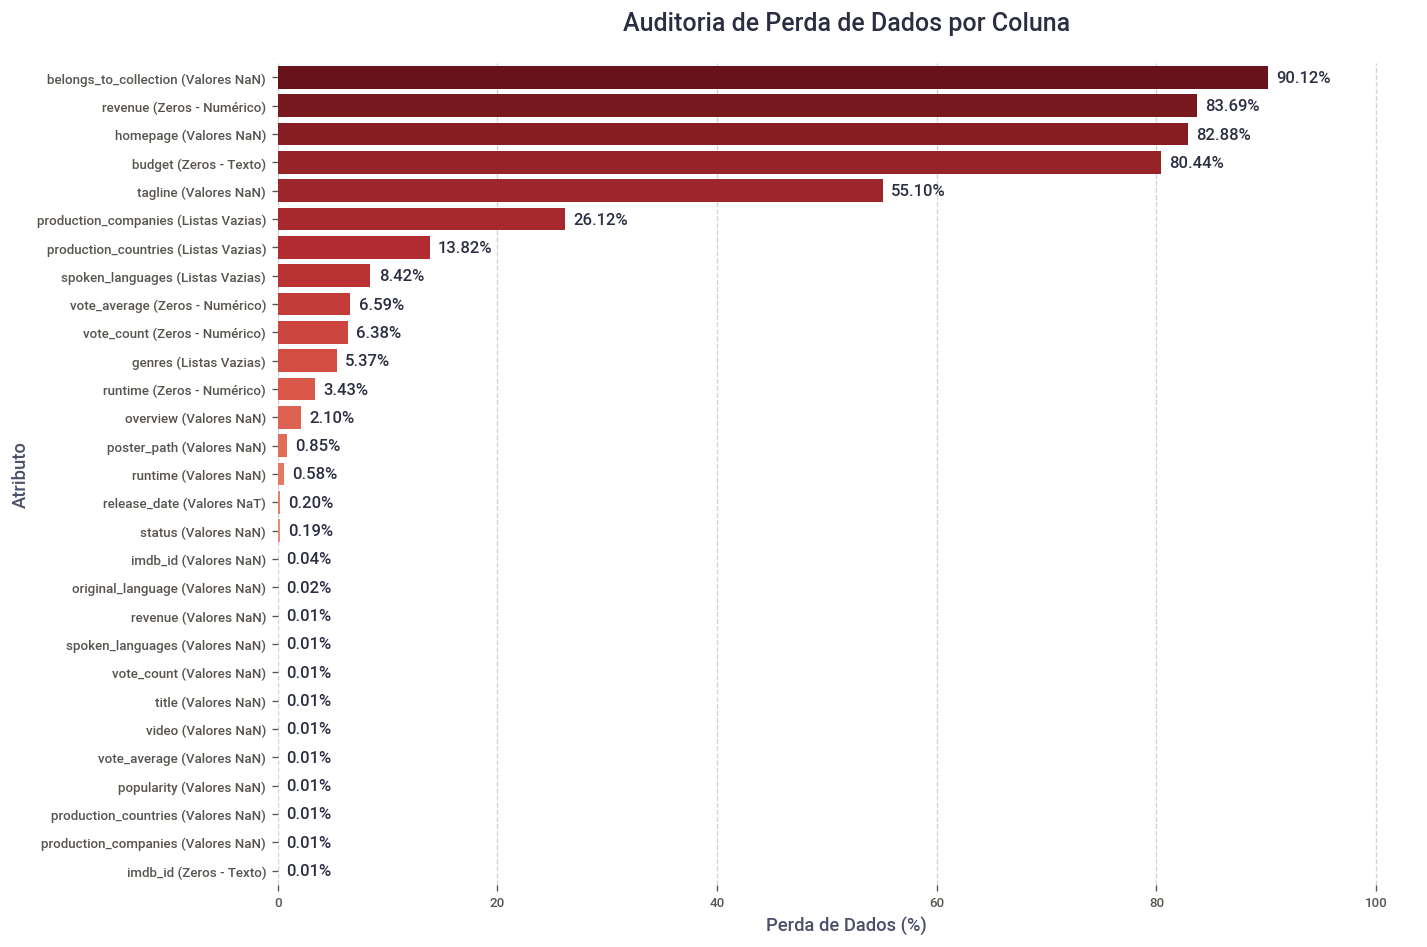

In [21]:
graf.grafico_percentual_missing_data(df_resumo_nulos)

In [22]:
# DROPANDO AS COLUNAS COM MAIS DE 50% DE PERDA DE DADOS e QUE NÃO SÃO RELEVANTES PARA O NOSSO PROJETO
colunas_para_dropar = ['homepage', 'tagline', 'overview','poster_path', 'status', 'imdb_id']

df_movies_limpo = df_movies.drop(columns=colunas_para_dropar)

In [23]:
mask_listas_vazias = (
    (df_movies['production_companies'] == '[]') |
    (df_movies['production_countries'] == '[]') |
    (df_movies['spoken_languages'] == '[]') |
    (df_movies['genres'] == '[]')
)

display(tb.destacar_anomalias(
    df=df_movies,
    mascara=mask_listas_vazias,
    colunas_destaque=[
        'production_companies', 
        'production_countries', 
        'spoken_languages', 
        'genres'
    ],
    colunas_contexto=[
        'title',
        'vote_average', 
        'vote_count'
    ],
    valores_anomalos=['[]'],
    qtd_linhas=20,
    caption="Colunas com Listas Vazias e seu Contexto"
))

,title,vote_average,vote_count,production_companies,production_countries,spoken_languages,genres
50,Guardian Angel,6.3,3,[],[],[],"[{'id': 28, 'name': 'Action'}, {'id': 53, 'name': 'Thriller'}, {'id': 18, 'name': 'Drama'}]"
52,Lamerica,7.7,11,[],"[{'iso_3166_1': 'IT', 'name': 'Italy'}, {'iso_3166_1': 'FR', 'name': 'France'}, {'iso_3166_1': 'CH', 'name': 'Switzerland'}]","[{'iso_639_1': 'sq', 'name': 'shqip'}, {'iso_639_1': 'it', 'name': 'Italiano'}]","[{'id': 18, 'name': 'Drama'}, {'id': 10769, 'name': 'Foreign'}]"
55,Kids of the Round Table,3.0,1,"[{'name': 'Telefilm Canada', 'id': 7320}, {'name': 'Melenny Productions', 'id': 10260}]",[],"[{'iso_639_1': 'en', 'name': 'English'}]",[]
57,The Postman,7.6,181,[],"[{'iso_3166_1': 'BE', 'name': 'Belgium'}, {'iso_3166_1': 'FR', 'name': 'France'}, {'iso_3166_1': 'IT', 'name': 'Italy'}]","[{'iso_639_1': 'it', 'name': 'Italiano'}, {'iso_639_1': 'es', 'name': 'Español'}]","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10749, 'name': 'Romance'}]"
58,The Confessional,6.5,2,[],"[{'iso_3166_1': 'CA', 'name': 'Canada'}]","[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': 'fr', 'name': 'Français'}]","[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'name': 'Drama'}, {'id': 9648, 'name': 'Mystery'}]"
83,Last Summer in the Hamptons,0.0,0,[],[],[],[]
104,Nobody Loves Me,5.1,5,[],"[{'iso_3166_1': 'DE', 'name': 'Germany'}]","[{'iso_639_1': 'de', 'name': 'Deutsch'}]","[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"
106,Catwalk,7.0,2,[],[],"[{'iso_639_1': 'en', 'name': 'English'}]","[{'id': 99, 'name': 'Documentary'}]"
107,Headless Body in Topless Bar,0.0,0,[],[],[],"[{'id': 80, 'name': 'Crime'}]"
114,Anne Frank Remembered,7.3,4,[],"[{'iso_3166_1': 'GB', 'name': 'United Kingdom'}, {'iso_3166_1': 'US', 'name': 'United States of America'}, {'iso_3166_1': 'NL', 'name': 'Netherlands'}]","[{'iso_639_1': 'en', 'name': 'English'}]","[{'id': 99, 'name': 'Documentary'}, {'id': 18, 'name': 'Drama'}, {'id': 10769, 'name': 'Foreign'}]"


In [24]:
display(tb.estilizar_tabela(
    df_movies_limpo[df_movies_limpo['release_date'].isna()],
    colunas_selecionadas=['title', 'release_date'],
    caption="Filmes com Data de Lançamento Nula"
))

,title,release_date
711,War Stories Our Mother Never Told Us,nan
734,Vermont Is for Lovers,nan
3460,"Jails, Hospitals & Hip-Hop",nan
3628,Boricua's Bond,nan
5879,Divine Intervention,nan
13839,Bling: A Planet Rock,nan
14801,Dead Ahead: The Exxon Valdez Disaster,nan
16836,Das Experiment 770 - Gebären auf Befehl,nan
16953,Connections,nan
17339,Human Failure,nan


In [25]:
display(tb.estilizar_tabela(
    df=df_movies_limpo['vote_average']
        .describe()
        .to_frame(),
    caption="Descrição detalhada coluna `vote_average` "
))

,vote_average
count,45460.0
mean,5.6
std,1.9
min,0.0
25%,5.0
50%,6.0
75%,6.8
max,10.0


In [26]:
display(tb.destacar_anomalias(
    df=df_movies_limpo,
    mascara=df_movies_limpo['vote_average'] == 0,
    colunas_destaque=['vote_average'],
    colunas_contexto=['title', 'genres', 'vote_count'],
    qtd_linhas=10,
    caption="Anomalia: Filmes com Média de Notas Zeradas"
))

,title,genres,vote_count,vote_average
83,Last Summer in the Hamptons,[],0,0.0
107,Headless Body in Topless Bar,"[{'id': 80, 'name': 'Crime'}]",0,0.0
126,Jupiter's Wife,[],0,0.0
132,Sonic Outlaws,"[{'id': 10402, 'name': 'Music'}, {'id': 99, 'name': 'Documentary'}]",0,0.0
137,Target,[],0,0.0
164,Feast of July,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name': 'Crime'}]",0,0.0
280,New York Cop,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'name': 'Thriller'}, {'id': 80, 'name': 'Crime'}, {'id': 18, 'name': 'Drama'}]",0,0.0
390,Desert Winds,[],0,0.0
395,Homage,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'name': 'Drama'}]",0,0.0
397,Open Season,"[{'id': 35, 'name': 'Comedy'}]",0,0.0


In [27]:
display(tb.destacar_anomalias(
    df=df_movies_limpo,
    mascara=df_movies_limpo['vote_count'] == 0,
    colunas_destaque=['vote_count'],
    colunas_contexto=['title', 'genres', 'vote_average'],
    qtd_linhas=10,
    caption='Anomalia: Filmes sem Votos'
))

,title,genres,vote_average,vote_count
83,Last Summer in the Hamptons,[],0.0,0
107,Headless Body in Topless Bar,"[{'id': 80, 'name': 'Crime'}]",0.0,0
126,Jupiter's Wife,[],0.0,0
132,Sonic Outlaws,"[{'id': 10402, 'name': 'Music'}, {'id': 99, 'name': 'Documentary'}]",0.0,0
137,Target,[],0.0,0
164,Feast of July,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name': 'Crime'}]",0.0,0
280,New York Cop,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'name': 'Thriller'}, {'id': 80, 'name': 'Crime'}, {'id': 18, 'name': 'Drama'}]",0.0,0
390,Desert Winds,[],0.0,0
395,Homage,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'name': 'Drama'}]",0.0,0
397,Open Season,"[{'id': 35, 'name': 'Comedy'}]",0.0,0


In [28]:
# Analisando os filmes que tem 0 votos e 0 de media

zero_votos_media = (
    (df_movies_limpo['vote_count'] == 0) & 
    (df_movies_limpo['vote_average'] == 0)
)

# Quantidade de filmes com 0 votos e 0 de media
numero_filmes_zero_votos_media = df_movies_limpo[zero_votos_media].shape[0]
per_filmes_zero_votos_media = numero_filmes_zero_votos_media / len(df_movies_limpo) * 100

# Exibindo os resultados
display(f"Numero de filmes com 0 votos e 0 de media: {numero_filmes_zero_votos_media}")

display(f"Percentual de filmes com 0 votos e 0 de media: {per_filmes_zero_votos_media}")

'Numero de filmes com 0 votos e 0 de media: 2899'

'Percentual de filmes com 0 votos e 0 de media: 6.376193199313773'

In [29]:
# Analisando os filmes que tem 0 votos e media maior que 0

zero_votos_media_maior_que_zero = (
    (df_movies_limpo['vote_count'] == 0) &
    (df_movies_limpo['vote_average'] > 0)
)

# Calculando o numero e percentual de filmes com 0 votos e media maior que 0
numero_filmes_zero_votos_media_maior_que_zero = df_movies_limpo[zero_votos_media_maior_que_zero].shape[0]
per_filmes_zero_votos_media_maior_que_zero = numero_filmes_zero_votos_media_maior_que_zero / len(df_movies_limpo) * 100

# Exibindo os resultados
display(f"Numero de filmes com 0 votos e media maior que 0: {numero_filmes_zero_votos_media_maior_que_zero}")

display(f"Percentual de filmes com 0 votos e media maior que 0: {per_filmes_zero_votos_media_maior_que_zero}")

'Numero de filmes com 0 votos e media maior que 0: 0'

'Percentual de filmes com 0 votos e media maior que 0: 0.0'

In [30]:
# Analisando os filmes que tem media 0 e votos maior que 0

zero_media_votos_maior_que_zero = (
    (df_movies_limpo['vote_count'] > 0) &
    (df_movies_limpo['vote_average'] == 0)
)

# Calculando o numero e percentual de filmes com media 0 e votos maior que 0
numero_filmes_zero_media_votos_maior_que_zero = df_movies_limpo[zero_media_votos_maior_que_zero].shape[0]
per_filmes_zero_media_votos_maior_que_zero = numero_filmes_zero_media_votos_maior_que_zero / len(df_movies_limpo) * 100

# Exibindo os resultados
display(f"Numero de filmes com media 0 e votos maior que 0: {numero_filmes_zero_media_votos_maior_que_zero}")   

display(f"Percentual de filmes com media 0 e votos maior que 0: {per_filmes_zero_media_votos_maior_que_zero}")

'Numero de filmes com media 0 e votos maior que 0: 99'

'Percentual de filmes com media 0 e votos maior que 0: 0.21774512822768663'

In [31]:
display(tb.destacar_anomalias(
    df=df_movies_limpo,
    mascara=zero_media_votos_maior_que_zero,
    colunas_destaque=['vote_average', 'vote_count'],
    colunas_contexto=['title'],
    caption='Anomalia: Filmes com Média de Notas 0 e Número de Votos Superior a 0 '
))

,title,vote_average,vote_count
554,"The Beans of Egypt, Maine",0.0,1
1371,Inside,0.0,1
1564,Alive and Kicking,0.0,1
12274,Joe and Max,0.0,1
13226,Pete Seeger: The Power of Song,0.0,1
14171,Mr. Robinson Crusoe,0.0,1
14804,Me and Him,0.0,1
15514,Mammy,0.0,1
15748,Pride of the Marines,0.0,2
16653,Girls About Town,0.0,1


In [32]:
# Dropando filmes com 0 votos
df_movies_limpo = df_movies_limpo[df_movies_limpo['vote_count'] > 0]

In [33]:
display(tb.estilizar_tabela(
    df=df_movies_limpo[df_movies_limpo['vote_average'] == 0]
        .describe()
))

,revenue,runtime,vote_average,vote_count
count,US$ 99,99 min,99.0,99
mean,US$ 157,83 min,0.0,3
std,"US$ 1,558",35 min,0.0,7
min,US$ 0,0 min,0.0,1
25%,US$ 0,78 min,0.0,1
50%,US$ 0,90 min,0.0,1
75%,US$ 0,102 min,0.0,1
max,"US$ 15,504",191 min,0.0,58


In [34]:
# Analisando os filmes que tem runtime 0 ou nulo

no_runtime = (
    (df_movies_limpo['runtime'] == 0) | 
    (df_movies_limpo['runtime'].isnull())
)

# Calculando o numero e percentual de filmes com runtime 0 ou nulo
numero_filmes_no_runtime = no_runtime.sum()
per_filmes_no_runtime = numero_filmes_no_runtime / len(df_movies_limpo) * 100

display(f"Numero de filmes com runtime 0 ou nulo: {numero_filmes_no_runtime}")
display(f"Percentual de filmes com runtime 0 ou nulo: {per_filmes_no_runtime}")


'Numero de filmes com runtime 0 ou nulo: 1371'

'Percentual de filmes com runtime 0 ou nulo: 3.2212588989920348'

In [35]:
display(tb.destacar_anomalias(
    df=df_movies_limpo,
    mascara=no_runtime,
    colunas_destaque=['runtime'],
    colunas_contexto=['title', 'genres', 'vote_average', 'vote_count'],
    qtd_linhas=10,
    caption=('Anomalia: Filmes com Tempo de Rodagem Zerado')
))

,title,genres,vote_average,vote_count,runtime
222,Dream Man,"[{'id': 53, 'name': 'Thriller'}]",2.5,1,0 min
224,Destiny Turns on the Radio,"[{'id': 80, 'name': 'Crime'}, {'id': 35, 'name': 'Comedy'}, {'id': 14, 'name': 'Fantasy'}]",5.3,9,0 min
398,Dos Crímenes,[],5.0,1,0 min
554,"The Beans of Egypt, Maine",[],0.0,1,0 min
634,Peanuts – Die Bank zahlt alles,"[{'id': 35, 'name': 'Comedy'}]",4.0,1,nan
667,The Run of the Country,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'name': 'Romance'}]",8.0,2,0 min
679,Under The Domim Tree,"[{'id': 18, 'name': 'Drama'}, {'id': 10769, 'name': 'Foreign'}]",6.5,2,0 min
792,A Boy Called Hate,[],6.0,2,0 min
802,Diebinnen,"[{'id': 18, 'name': 'Drama'}]",4.0,1,nan
832,Mille bolle blu,[],6.0,1,0 min


In [36]:
# Dropando coluna runtime
df_movies_limpo = df_movies_limpo.dropna(subset=['runtime'])
df_movies_limpo = df_movies_limpo[df_movies_limpo['runtime'] > 0]

In [37]:
# Dropando as linhas com menos de 1% de perda de dados

# criando uma lista de colunas que tem perda de dados menor ou igual a 1%
indices_limpos = [i.split(' (')[0] for i in df_resumo_nulos[df_resumo_nulos['Perda de Dados (%)'] < 1].index]

# Criando uma lista segura de colunas para drop, garantindo que elas existam no DataFrame
lista_segura = [coluna for coluna in indices_limpos if coluna in df_movies_limpo.columns]

# Dropando as linhas com menos de 1% de perda de dados
df_movies_limpo = df_movies_limpo.dropna(subset=lista_segura)

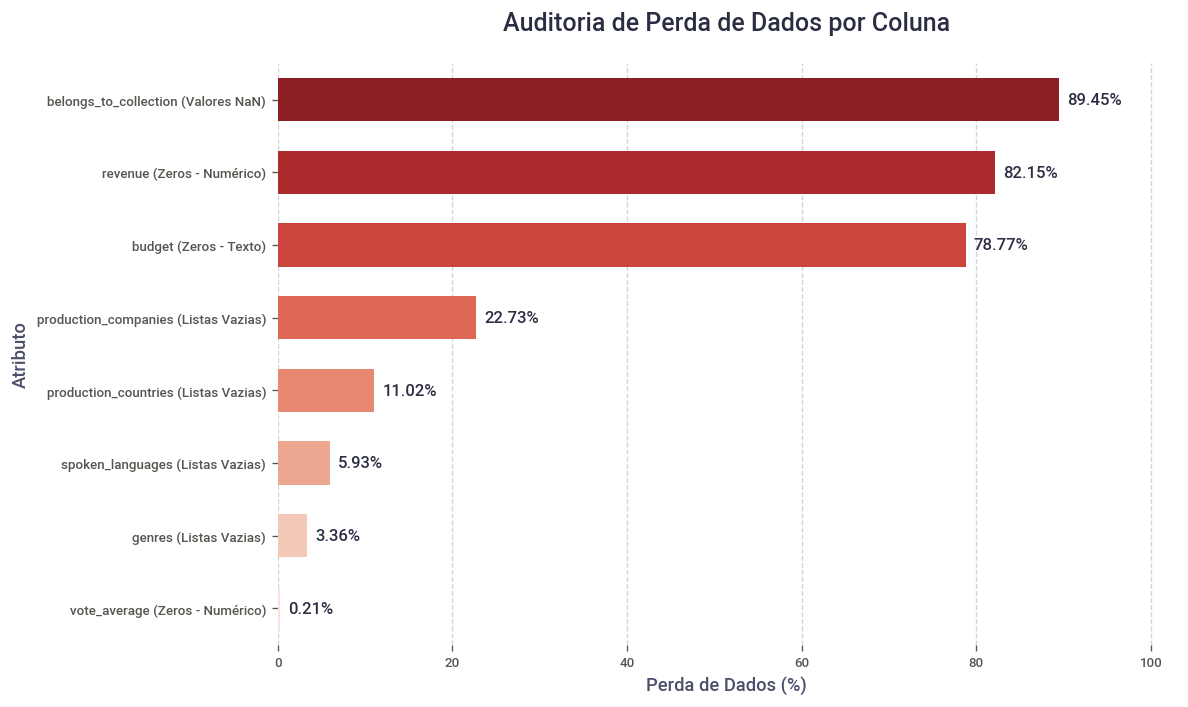

In [38]:
df_resumo_nulos_limpo = dq.resumo_qualidade(df_movies_limpo)
graf.grafico_percentual_missing_data(df_resumo_nulos_limpo, tamanho_figura=(10,6), width=0.6)

In [39]:
display(f"Número de linhas após limpeza: {len(df_movies_limpo)}")
display(f"Número de linhas removidas: {len(df_movies) - len(df_movies_limpo)}")

'Número de linhas após limpeza: 41164'

'Número de linhas removidas: 4302'

## Tratamento de Dados Faltantes e Feature Engineering

### Seleção de Atributos (Drop de Colunas)
Removeremos colunas que possuem alta cardinalidade de texto, dados irrelevantes para o escopo estatístico ou excesso de ruído visual:

- Colunas descartadas: `homepage`, `poster_path`, `overview`, `tagline`, `status` e `imdb_id`.

### Engenharia de Variáveis
- `is_franchise`: Transformaremos a coluna `belongs_to_collection` (que possui ~89% de nulos) em uma variável booleana. A ausência de dados aqui indica que o filme é uma obra única, não uma falha de coleta.

- `budget` & `revenue`: Fpi identificado um volume crítico de valores zerados (~80%). Optaremos por manter as colunas para análises futuras, mas converteremos todos os 0 em NaN para evitar distorções em cálculos de média e mediana. E também tranformaremos em milhões para facilitar.

- `production_companies`, `production_countries`, `spoken_languages ` & `genres`: Foi identificado que essa colunas estão estruturasdas com um JSON serializado, serão convertidas para Listas Nativas e salvas.Posteriormente serão explodidas e salvas individualmente em diferntes datasets. 
  - Também percebeu-se que existem quantias significativas de dados flatantes, impossivel dropar as linhas, deviso a alta densidade de dados, assim como é também não podem ser excluidas colunas com tal valor de negócio. Sendo assim, serão substituidas as Listas Vazias por termos que expressem a falta de informação referente a coluna.


### Limpeza Cirúrgica de Linhas
Para manter a precisão das métricas, aplicaremos o descarte de linhas nos seguintes cenários:

- Ciscos Estatísticos (Nulos < 1%): Remoção de linhas com dados faltantes em `runtime`, `release_date`, `original_language`, etc. Devido ao tamanho do dataset, o impacto dessa exclusão será desprezível. 

- Falta de Avaliação: Exclusão de aproximadamente 6,38% da base que não possui qualquer registro de voto ou média de avaliação, dado essencial para o estudo de engajamento.

- Notas Zeradas vs. Outliers: Filmes com vote_average igual a 0 ou com poucos votos podem representar dados de baixa qualidade, eles serão analisados detalhadamente na seção de Outliers para evitar a exclusão de filmes que são apenas impopulares, e não necessariamente "dados faltantes".
